# HITO 3 - Modelado, Entrenamiento y Validacion
## Asignatura: Desarrollo e Integracion de Servicios de IA (DISIA)
### Proyecto: Deteccion de Intrusos en Sistemas IIoT (X-IIoTID)

En este cuaderno se desarrolla la fase de modelado, entrenamiento y validacion a partir de los artefactos generados en el Hito 2. Se mantiene el mismo estilo de trabajo usado en los hitos anteriores: bloques markdown breves, codigo ejecutable y figuras/tablas impresas dentro del propio notebook.

El flujo de trabajo previsto del proyecto es **secuencial**: primero se ejecuta `EDA/HITO_2.ipynb` y despues este cuaderno. Por tanto, el Hito 3 parte de los artefactos exportados por el Hito 2 en `DATA` y no rehace por su cuenta el preprocesamiento anterior.

### Alcance del cuaderno
1. Se compara el rendimiento de varias familias de modelos, incluyendo `XGBoost`, `ExtraTrees`, `RandomForest`, `MLP` y una `DNN` en PyTorch.
2. Se documentan las caracteristicas del hardware, del software y del lenguaje de programacion utilizados en la ejecucion.
3. Se reportan metricas en `train`, `validacion` y `test` para estudiar aprendizaje y generalizacion.
4. Se incluyen metricas tecnicas del problema (`accuracy`, `precision`, `recall`, `F1`, `FPR`, `AUC-ROC`) y metricas operativas de negocio.
5. Se muestran curvas de aprendizaje y comparativas globales entre particiones.
6. Se guardan tablas, predicciones, modelos, historiales y figuras en una carpeta de resultados especifica.

### Modelos incluidos
- `DecisionTree`: referencia interpretable basada en arboles.
- `RandomForest`: ensamble bagging, candidato fuerte en datos tabulares.
- `ExtraTrees`: ensamble de arboles altamente aleatorizado para ampliar la comparativa de familias tree-based.
- `XGBoost`: boosting de arboles escalable y muy competitivo en tabular.
- `LogisticRegression`: baseline lineal multiclase.
- `GaussianNB`: baseline probabilistico simple.
- `MLP`: red neuronal multicapa de `scikit-learn`.
- `DNN`: red neuronal profunda en PyTorch con `batch norm`, `dropout` y parada temprana.

---
### Indice del notebook
1. [Carga de datos exportados por el Hito 2](#1)
2. [Definicion del problema, taxonomia y metricas operativas](#2)
3. [Configuracion experimental, hardware y referencias](#3)
4. [Entrenamiento y evaluacion de modelos](#4)
5. [Resultados globales en train, validacion y test](#5)
6. [Curvas de aprendizaje y dinamica de entrenamiento](#6)
7. [Resultados finales en test y metricas de negocio](#7)
8. [Analisis detallado de los mejores modelos](#8)
9. [Conclusiones del modelado](#9)


In [1]:
from collections import Counter
from copy import deepcopy
from pathlib import Path
import gc
import os
import platform
import random
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="muted")
pd.options.display.float_format = lambda x: f"{x:.4f}"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, (psutil.cpu_count(logical=False) or 2) - 1))


### 1. Carga de datos exportados por el Hito 2 <a name="1"></a>

Este cuaderno asume que el **Hito 2 ya se ha ejecutado antes** y que ha dejado guardados en `DATA`:

- `X_train_final.csv`, `X_val_final.csv`, `X_test_final.csv`
- `y_train_class1.csv`, `y_val_class1.csv`, `y_test_class1.csv`
- `y_train_class2.csv`, `y_val_class2.csv`, `y_test_class2.csv`
- `y_train_class3.csv`, `y_val_class3.csv`, `y_test_class3.csv`

Este diseño respeta la lógica natural del proyecto: el Hito 2 prepara y persiste los datos; el Hito 3 consume exactamente esos artefactos para entrenar y comparar modelos. Si falta alguno de ellos, la ejecución debe detenerse y volver al Hito 2.


In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / ".git").exists():
            return candidate
    return cwd


PROJECT_ROOT = resolve_project_root()
DATA_DIR = PROJECT_ROOT / "DATA"
RESULTS_DIR = PROJECT_ROOT / "RESULTADOS_HITO3"
MODELS_DIR = RESULTS_DIR / "modelos"
PREDICTIONS_DIR = RESULTS_DIR / "predicciones"
TABLES_DIR = RESULTS_DIR / "tablas"
FIGURES_DIR = RESULTS_DIR / "figuras"
HISTORIES_DIR = RESULTS_DIR / "historiales"

for directory in [DATA_DIR, RESULTS_DIR, MODELS_DIR, PREDICTIONS_DIR, TABLES_DIR, FIGURES_DIR, HISTORIES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


N_JOBS = 1

required_files = [
    DATA_DIR / "X_train_final.csv",
    DATA_DIR / "X_val_final.csv",
    DATA_DIR / "X_test_final.csv",
    DATA_DIR / "y_train_class1.csv",
    DATA_DIR / "y_val_class1.csv",
    DATA_DIR / "y_test_class1.csv",
    DATA_DIR / "y_train_class2.csv",
    DATA_DIR / "y_val_class2.csv",
    DATA_DIR / "y_test_class2.csv",
    DATA_DIR / "y_train_class3.csv",
    DATA_DIR / "y_val_class3.csv",
    DATA_DIR / "y_test_class3.csv",
]

missing_files = [path.name for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Faltan artefactos exportados por el Hito 2 en DATA. "
        "Ejecuta primero 'EDA/HITO_2.ipynb' para generarlos. "
        f"Archivos ausentes: {missing_files}"
    )

X_train = pd.read_csv(DATA_DIR / "X_train_final.csv").astype(np.float32)
X_val = pd.read_csv(DATA_DIR / "X_val_final.csv").astype(np.float32)
X_test = pd.read_csv(DATA_DIR / "X_test_final.csv").astype(np.float32)

y_train_type = pd.read_csv(DATA_DIR / "y_train_class1.csv")["class1"].astype(str)
y_val_type = pd.read_csv(DATA_DIR / "y_val_class1.csv")["class1"].astype(str)
y_test_type = pd.read_csv(DATA_DIR / "y_test_class1.csv")["class1"].astype(str)

y_train_cat = pd.read_csv(DATA_DIR / "y_train_class2.csv")["class2"].astype(str)
y_val_cat = pd.read_csv(DATA_DIR / "y_val_class2.csv")["class2"].astype(str)
y_test_cat = pd.read_csv(DATA_DIR / "y_test_class2.csv")["class2"].astype(str)

y_train_bin = pd.read_csv(DATA_DIR / "y_train_class3.csv")["class3"].astype(str)
y_val_bin = pd.read_csv(DATA_DIR / "y_val_class3.csv")["class3"].astype(str)
y_test_bin = pd.read_csv(DATA_DIR / "y_test_class3.csv")["class3"].astype(str)

split_summary = pd.DataFrame(
    {
        "conjunto": ["train", "validacion", "test"],
        "filas_X": [len(X_train), len(X_val), len(X_test)],
        "filas_y": [len(y_train_type), len(y_val_type), len(y_test_type)],
        "columnas_X": [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
    }
)

display(split_summary)
print("Project root:", PROJECT_ROOT)
print("Artefactos del Hito 2 disponibles en DATA:", True)

split_summary.to_csv(TABLES_DIR / "resumen_particiones.csv", index=False)


,conjunto,filas_X,filas_y,columnas_X
0,train,574583,574583,34
1,validacion,123125,123125,34
2,test,123126,123126,34


Project root: C:\Users\marce\OneDrive\Escritorio\DSIA\Proyecto-DISIA
Artefactos del Hito 2 disponibles en DATA: True


### 2. Definicion del problema, taxonomia y metricas operativas <a name="2"></a>

El objetivo principal del entrenamiento es `class1`, es decir, el **tipo exacto de trafico**. A partir de esa salida se derivan de forma determinista:

1. `class2`: categoria de ataque.
2. `class3`: decision binaria `normal` frente a `attack`.

Ademas, se incluyen las metricas operativas definidas en el Hito 1:

- `alertas_manuales = TP + FP`
- `coste_fp = FP * t_rev * C_hora`
- `coste_total = (TP + FP) * t_rev * C_hora`

Para `t_rev` ni `C_hora`, se adopta un **escenario ilustrativo** y transparente para poder comparar modelos en terminos de impacto operativo.


In [3]:
mapping_df = pd.DataFrame(
    {
        "class1": pd.concat([y_train_type, y_val_type, y_test_type], ignore_index=True),
        "class2": pd.concat([y_train_cat, y_val_cat, y_test_cat], ignore_index=True),
        "class3": pd.concat([y_train_bin, y_val_bin, y_test_bin], ignore_index=True),
    }
).drop_duplicates(subset="class1").sort_values("class1").reset_index(drop=True)

type_to_category = mapping_df.set_index("class1")["class2"].to_dict()
type_to_binary = mapping_df.set_index("class1")["class3"].to_dict()

class_inventory = mapping_df.copy()
class_inventory["soporte_train"] = class_inventory["class1"].map(y_train_type.value_counts()).fillna(0).astype(int)
class_inventory = class_inventory.sort_values("soporte_train", ascending=False).reset_index(drop=True)

REVIEW_MINUTES = 3.0
HOURLY_COST_EUR = 25.0

assumptions_df = pd.DataFrame(
    [
        ["t_rev_min", REVIEW_MINUTES, "Minutos medios para revisar una alerta manualmente."],
        ["C_hora_eur", HOURLY_COST_EUR, "Coste horario estimado del operador de seguridad."],
        ["lenguaje", "Python", "Implementacion del experimento y del notebook."],
    ],
    columns=["parametro", "valor", "descripcion"],
)

display(class_inventory)
display(assumptions_df)
print("Numero de clases en class1:", class_inventory["class1"].nunique())
print("Interpretacion:", 1, "clase normal +", class_inventory["class1"].nunique() - 1, "tipos de ataque.")

class_inventory.to_csv(TABLES_DIR / "inventario_clases.csv", index=False)
assumptions_df.to_csv(TABLES_DIR / "supuestos_operativos.csv", index=False)


,class1,class2,class3,soporte_train
0,normal,normal,normal,294991
1,rdos,rdos,attack,98744
2,scanning_vulnerability,reconnaissance,attack,37029
3,generic_scanning,reconnaissance,attack,35141
4,bruteforce,weaponization,attack,33249
5,mqtt_cloud_broker_subscription,lateral _movement,attack,16511
6,discovering_resources,reconnaissance,attack,16253
7,exfiltration,exfiltration,attack,15565
8,insider_malcious,weaponization,attack,12123
9,modbus_register_reading,lateral _movement,attack,4126


,parametro,valor,descripcion
0,t_rev_min,3.0000,Minutos medios para revisar una alerta manualm...
1,C_hora_eur,25.0000,Coste horario estimado del operador de seguridad.
2,lenguaje,Python,Implementacion del experimento y del notebook.


Numero de clases en class1: 19
Interpretacion: 1 clase normal + 18 tipos de ataque.


### 3. Configuracion experimental, hardware y referencias <a name="3"></a>

Todos los modelos se entrenan sobre las mismas `34` variables finales del Hito 2 y bajo el mismo protocolo experimental. Ademas de la comparativa de rendimiento, se documenta el contexto de ejecucion para que la memoria pueda indicar con precision:

- hardware utilizado,
- software y versiones,
- lenguaje de programacion,
- bibliografia basica que justifica la seleccion de modelos.

La tabla de referencias combina fuentes clasicas de los algoritmos con trabajos orientados a IDS/IIoT para justificar por que tiene sentido comparar familias basadas en arboles, boosting y redes neuronales en este problema.


In [4]:
experiment_context = pd.DataFrame(
    [
        ["SO", platform.platform()],
        ["CPU identificada por Python", platform.processor()],
        ["Arquitectura", platform.machine()],
        ["Nucleos fisicos", psutil.cpu_count(logical=False)],
        ["Nucleos logicos", psutil.cpu_count(logical=True)],
        ["RAM total (GB)", round(psutil.virtual_memory().total / (1024 ** 3), 2)],
        ["CUDA disponible", torch.cuda.is_available()],
        ["Dispositivo de entrenamiento", "CPU"],
    ],
    columns=["elemento", "valor"],
)

software_context = pd.DataFrame(
    [
        ["Lenguaje", "Python", platform.python_version()],
        ["scikit-learn", "ML clasico", __import__("sklearn").__version__],
        ["xgboost", "boosting", __import__("xgboost").__version__],
        ["torch", "DNN", torch.__version__],
        ["pandas", "datos", pd.__version__],
        ["numpy", "calculo", np.__version__],
    ],
    columns=["componente", "rol", "version"],
)

references_df = pd.DataFrame(
    [
        ["RandomForest", "Breiman (2001)", "Random Forests", "doi:10.1023/A:1010933404324"],
        ["ExtraTrees", "Geurts et al. (2006)", "Extremely Randomized Trees", "doi:10.1007/s10994-006-6226-1"],
        ["XGBoost", "Chen y Guestrin (2016)", "XGBoost: A Scalable Tree Boosting System", "doi:10.1145/2939672.2939785"],
        ["DNN", "LeCun, Bengio y Hinton (2015)", "Deep Learning", "doi:10.1038/nature14539"],
        ["IIoT ensembles", "Awotunde et al. (2023)", "An Ensemble Tree-Based Model for Intrusion Detection in IIoT Networks", "doi:10.3390/app13042479"],
        ["IoT/IDS review", "Rafique et al. (2024)", "Machine Learning and Deep Learning Techniques for IoT Network Anomaly Detection", "doi:10.3390/s24061968"],
    ],
    columns=["tema", "autores", "referencia", "enlace_doi"],
)

display(experiment_context)
display(software_context)
display(references_df)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train_type)
y_val_enc = label_encoder.transform(y_val_type)
y_test_enc = label_encoder.transform(y_test_type)
normal_class_code = int(label_encoder.transform(["normal"])[0])
n_classes = len(label_encoder.classes_)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(n_classes),
    y=y_train_enc,
)
class_weight_lookup = {cls: weight for cls, weight in zip(np.arange(n_classes), class_weights)}
sample_weight_train = np.array([class_weight_lookup[label] for label in y_train_enc], dtype=np.float32)

X_train_np = X_train.to_numpy(dtype=np.float32)
X_val_np = X_val.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)

model_catalog = pd.DataFrame(
    [
        ["DecisionTree", "Arbol de decision", "Referencia interpretable y rapida.", "class_weight='balanced', max_depth=25, min_samples_leaf=5"],
        ["RandomForest", "Bosque aleatorio", "Ensamble bagging fuerte en tabular.", "n_estimators=120, class_weight='balanced_subsample', min_samples_leaf=2, n_jobs=1"],
        ["ExtraTrees", "Bosque extremadamente aleatorizado", "Otro ensamble de arboles para ampliar la comparativa tree-based.", "n_estimators=140, class_weight='balanced', min_samples_leaf=2, n_jobs=1"],
        ["XGBoost", "Gradient boosting de arboles", "Comparativa explicita frente a RandomForest y otros arboles.", "tree_method='hist', n_estimators=140, max_depth=8, learning_rate=0.08, n_jobs=1"],
        ["LogisticRegression", "Regresion logistica", "Baseline lineal multiclase.", "solver='saga', class_weight='balanced', max_iter=140, n_jobs=1"],
        ["GaussianNB", "Naive Bayes gaussiano", "Baseline probabilistico simple y muy rapido.", "Configuracion por defecto"],
        ["MLP", "Red neuronal multicapa", "Comparativa neuronal clasica en scikit-learn.", "hidden_layer_sizes=(128, 64, 32), early_stopping=True, max_iter=25"],
        ["DNN", "Red neuronal profunda", "Alternativa neuronal adicional con entrenamiento explicito y curvas por epoca.", "capas=(256, 128, 64), dropout=0.25, early_stopping=True"],
    ],
    columns=["modelo", "familia", "motivo", "configuracion_principal"],
)

display(model_catalog)
model_catalog.to_csv(TABLES_DIR / "catalogo_modelos.csv", index=False)
references_df.to_csv(TABLES_DIR / "referencias_modelos.csv", index=False)
experiment_context.to_csv(TABLES_DIR / "contexto_hardware.csv", index=False)
software_context.to_csv(TABLES_DIR / "contexto_software.csv", index=False)


def build_model_specs():
    return {
        "DecisionTree": {
            "family": "tree",
            "builder": lambda: DecisionTreeClassifier(
                random_state=SEED,
                class_weight="balanced",
                max_depth=25,
                min_samples_leaf=5,
            ),
        },
        "RandomForest": {
            "family": "tree_ensemble",
            "builder": lambda: RandomForestClassifier(
                n_estimators=120,
                random_state=SEED,
                class_weight="balanced_subsample",
                min_samples_leaf=2,
                n_jobs=N_JOBS,
            ),
        },
        "ExtraTrees": {
            "family": "tree_ensemble",
            "builder": lambda: ExtraTreesClassifier(
                n_estimators=140,
                random_state=SEED,
                class_weight="balanced",
                min_samples_leaf=2,
                n_jobs=N_JOBS,
            ),
        },
        "XGBoost": {
            "family": "boosting",
            "builder": lambda: XGBClassifier(
                objective="multi:softprob",
                num_class=n_classes,
                n_estimators=140,
                learning_rate=0.08,
                max_depth=8,
                min_child_weight=2,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=1.0,
                random_state=SEED,
                n_jobs=N_JOBS,
                tree_method="hist",
                eval_metric="mlogloss",
            ),
        },
        "LogisticRegression": {
            "family": "linear",
            "builder": lambda: LogisticRegression(
                random_state=SEED,
                class_weight="balanced",
                max_iter=140,
                solver="saga",
                n_jobs=N_JOBS,
            ),
        },
        "GaussianNB": {
            "family": "probabilistic",
            "builder": lambda: GaussianNB(),
        },
        "MLP": {
            "family": "neural",
            "builder": lambda: MLPClassifier(
                hidden_layer_sizes=(128, 64, 32),
                random_state=SEED,
                max_iter=25,
                early_stopping=True,
                validation_fraction=0.1,
                batch_size=2048,
                learning_rate_init=1e-3,
                n_iter_no_change=5,
                verbose=False,
            ),
        },
        "DNN": {
            "family": "neural",
            "builder": None,
        },
    }


model_specs = build_model_specs()


,elemento,valor
0,SO,Windows-11-10.0.26200-SP0
1,CPU identificada por Python,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD"
2,Arquitectura,AMD64
3,Nucleos fisicos,6
4,Nucleos logicos,12
5,RAM total (GB),31.9300
6,CUDA disponible,False
7,Dispositivo de entrenamiento,CPU


,componente,rol,version
0,Lenguaje,Python,3.14.3
1,scikit-learn,ML clasico,1.8.0
2,xgboost,boosting,3.2.0
3,torch,DNN,2.11.0+cpu
4,pandas,datos,3.0.2
5,numpy,calculo,2.4.4


,tema,autores,referencia,enlace_doi
0,RandomForest,Breiman (2001),Random Forests,doi:10.1023/A:1010933404324
1,ExtraTrees,Geurts et al. (2006),Extremely Randomized Trees,doi:10.1007/s10994-006-6226-1
2,XGBoost,Chen y Guestrin (2016),XGBoost: A Scalable Tree Boosting System,doi:10.1145/2939672.2939785
3,DNN,"LeCun, Bengio y Hinton (2015)",Deep Learning,doi:10.1038/nature14539
4,IIoT ensembles,Awotunde et al. (2023),An Ensemble Tree-Based Model for Intrusion Det...,doi:10.3390/app13042479
5,IoT/IDS review,Rafique et al. (2024),Machine Learning and Deep Learning Techniques ...,doi:10.3390/s24061968


,modelo,familia,motivo,configuracion_principal
0,DecisionTree,Arbol de decision,Referencia interpretable y rapida.,"class_weight='balanced', max_depth=25, min_sam..."
1,RandomForest,Bosque aleatorio,Ensamble bagging fuerte en tabular.,"n_estimators=120, class_weight='balanced_subsa..."
2,ExtraTrees,Bosque extremadamente aleatorizado,Otro ensamble de arboles para ampliar la compa...,"n_estimators=140, class_weight='balanced', min..."
3,XGBoost,Gradient boosting de arboles,Comparativa explicita frente a RandomForest y ...,"tree_method='hist', n_estimators=140, max_dept..."
4,LogisticRegression,Regresion logistica,Baseline lineal multiclase.,"solver='saga', class_weight='balanced', max_it..."
5,GaussianNB,Naive Bayes gaussiano,Baseline probabilistico simple y muy rapido.,Configuracion por defecto
6,MLP,Red neuronal multicapa,Comparativa neuronal clasica en scikit-learn.,"hidden_layer_sizes=(128, 64, 32), early_stoppi..."
7,DNN,Red neuronal profunda,Alternativa neuronal adicional con entrenamien...,"capas=(256, 128, 64), dropout=0.25, early_stop..."


### 4. Entrenamiento y evaluacion de modelos <a name="4"></a>

En esta seccion se entrena cada modelo y se evalua sobre `train`, `validacion` y `test`. Para cada familia se guardan:

1. el modelo entrenado,
2. predicciones de validacion y test,
3. metricas tecnicas del problema,
4. metricas operativas derivadas de la salida binaria,
5. historiales de entrenamiento cuando el algoritmo los expone.

La salida principal para seleccionar modelo sigue siendo la media simple entre `F1_bin`, `F1_cat` y `F1_type`, y el analisis se complementa con `FPR`, `AUC-ROC`, horas de revision y coste operativo.


In [5]:
class TorchDNNClassifier:
    def __init__(
        self,
        input_dim,
        num_classes,
        class_weights,
        hidden_dims=(256, 128, 64),
        dropout=0.25,
        lr=1e-3,
        batch_size=4096,
        max_epochs=14,
        patience=3,
        device="cpu",
        seed=SEED,
    ):
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.class_weights = np.asarray(class_weights, dtype=np.float32)
        self.hidden_dims = hidden_dims
        self.dropout = dropout
        self.lr = lr
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.device = device
        self.seed = seed
        self.model_ = None
        self.history_ = None

    def _build_model(self):
        torch.manual_seed(self.seed)
        layers = []
        in_dim = self.input_dim
        for hidden_dim in self.hidden_dims:
            layers.extend(
                [
                    nn.Linear(in_dim, hidden_dim),
                    nn.BatchNorm1d(hidden_dim),
                    nn.ReLU(),
                    nn.Dropout(self.dropout),
                ]
            )
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, self.num_classes))
        return nn.Sequential(*layers)

    def fit(self, X_train, y_train, X_val, y_val):
        self.model_ = self._build_model().to(self.device)
        optimizer = torch.optim.AdamW(self.model_.parameters(), lr=self.lr, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss(
            weight=torch.tensor(self.class_weights, dtype=torch.float32, device=self.device)
        )

        train_dataset = TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.long),
        )
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        X_val_tensor = torch.tensor(X_val, dtype=torch.float32, device=self.device)
        y_val_tensor = torch.tensor(y_val, dtype=torch.long, device=self.device)

        history_rows = []
        best_state = None
        best_val_f1 = -np.inf
        epochs_without_improvement = 0

        for epoch in range(1, self.max_epochs + 1):
            self.model_.train()
            running_loss = 0.0
            train_targets = []
            train_preds = []

            for batch_X, batch_y in train_loader:
                batch_X = batch_X.to(self.device)
                batch_y = batch_y.to(self.device)

                optimizer.zero_grad()
                logits = self.model_(batch_X)
                loss = criterion(logits, batch_y)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * batch_X.size(0)
                train_targets.append(batch_y.detach().cpu().numpy())
                train_preds.append(logits.argmax(dim=1).detach().cpu().numpy())

            train_targets = np.concatenate(train_targets)
            train_preds = np.concatenate(train_preds)
            train_loss = running_loss / len(train_dataset)
            train_f1 = f1_score(train_targets, train_preds, average="macro", zero_division=0)

            self.model_.eval()
            with torch.no_grad():
                val_logits = self.model_(X_val_tensor)
                val_loss = criterion(val_logits, y_val_tensor).item()
                val_preds = val_logits.argmax(dim=1).detach().cpu().numpy()
            val_f1 = f1_score(y_val, val_preds, average="macro", zero_division=0)

            history_rows.append(
                {
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "train_f1_type": train_f1,
                    "val_f1_type": val_f1,
                }
            )

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_state = deepcopy(self.model_.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= self.patience:
                break

        if best_state is not None:
            self.model_.load_state_dict(best_state)

        self.history_ = pd.DataFrame(history_rows)
        return self

    def predict_proba(self, X):
        self.model_.eval()
        dataset = TensorDataset(torch.tensor(X, dtype=torch.float32))
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
        probs = []
        with torch.no_grad():
            for (batch_X,) in loader:
                batch_X = batch_X.to(self.device)
                logits = self.model_(batch_X)
                probs.append(torch.softmax(logits, dim=1).detach().cpu().numpy())
        return np.vstack(probs)

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

    def save(self, path: Path):
        torch.save(
            {
                "state_dict": self.model_.state_dict(),
                "input_dim": self.input_dim,
                "num_classes": self.num_classes,
                "hidden_dims": self.hidden_dims,
                "dropout": self.dropout,
                "class_weights": self.class_weights.tolist(),
            },
            path,
        )


def classification_report_df(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return pd.DataFrame(report).T


def evaluate_type_predictions(y_true_type, y_true_cat, y_true_bin, y_pred_type, attack_scores):
    y_pred_type = pd.Series(y_pred_type)
    y_pred_cat = y_pred_type.map(type_to_category)
    y_pred_bin = y_pred_type.map(type_to_binary)

    y_true_attack = pd.Series(y_true_bin).map({"normal": 0, "attack": 1}).astype(int).to_numpy()
    y_pred_attack = pd.Series(y_pred_bin).map({"normal": 0, "attack": 1}).astype(int).to_numpy()
    tn, fp, fn, tp = confusion_matrix(y_true_attack, y_pred_attack, labels=[0, 1]).ravel()

    metrics = {
        "acc_type": accuracy_score(y_true_type, y_pred_type),
        "prec_type": precision_score(y_true_type, y_pred_type, average="macro", zero_division=0),
        "rec_type": recall_score(y_true_type, y_pred_type, average="macro", zero_division=0),
        "f1_type": f1_score(y_true_type, y_pred_type, average="macro", zero_division=0),
        "acc_cat": accuracy_score(y_true_cat, y_pred_cat),
        "prec_cat": precision_score(y_true_cat, y_pred_cat, average="macro", zero_division=0),
        "rec_cat": recall_score(y_true_cat, y_pred_cat, average="macro", zero_division=0),
        "f1_cat": f1_score(y_true_cat, y_pred_cat, average="macro", zero_division=0),
        "acc_bin": accuracy_score(y_true_bin, y_pred_bin),
        "prec_bin": precision_score(y_true_bin, y_pred_bin, average="binary", pos_label="attack", zero_division=0),
        "rec_bin": recall_score(y_true_bin, y_pred_bin, average="binary", pos_label="attack", zero_division=0),
        "f1_bin": f1_score(y_true_bin, y_pred_bin, average="binary", pos_label="attack", zero_division=0),
        "fpr_bin": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "auc_bin": roc_auc_score(y_true_attack, attack_scores) if len(np.unique(y_true_attack)) == 2 else np.nan,
        "tp_bin": int(tp),
        "tn_bin": int(tn),
        "fp_bin": int(fp),
        "fn_bin": int(fn),
    }

    metrics["manual_alerts"] = metrics["tp_bin"] + metrics["fp_bin"]
    metrics["manual_alerts_per_1000"] = metrics["manual_alerts"] / len(y_true_bin) * 1000
    metrics["review_hours"] = metrics["manual_alerts"] * (REVIEW_MINUTES / 60.0)
    metrics["review_hours_per_1000"] = metrics["review_hours"] / len(y_true_bin) * 1000
    metrics["fp_cost_eur"] = metrics["fp_bin"] * (REVIEW_MINUTES / 60.0) * HOURLY_COST_EUR
    metrics["total_operational_cost_eur"] = metrics["manual_alerts"] * (REVIEW_MINUTES / 60.0) * HOURLY_COST_EUR
    metrics["missed_attacks"] = metrics["fn_bin"]
    metrics["f1_mean"] = np.mean([metrics["f1_bin"], metrics["f1_cat"], metrics["f1_type"]])

    return metrics


def save_model_artifact(model_name, model_obj):
    if model_name == "DNN":
        model_obj.save(MODELS_DIR / f"{model_name}.pt")
    else:
        joblib.dump(model_obj, MODELS_DIR / f"{model_name}.joblib")


split_payload = {
    "train": (X_train_np, y_train_type, y_train_cat, y_train_bin),
    "val": (X_val_np, y_val_type, y_val_cat, y_val_bin),
    "test": (X_test_np, y_test_type, y_test_cat, y_test_bin),
}

eval_train_idx = np.random.default_rng(SEED).choice(len(X_train_np), size=min(60000, len(X_train_np)), replace=False)

metrics_rows = []
split_predictions = {"val": {}, "test": {}}
split_probabilities = {"train": {}, "val": {}, "test": {}}
reports_test = {}
history_frames = {}
trained_models = {}

for model_name, spec in model_specs.items():
    print(f"Entrenando {model_name}...")
    start_time = time.time()

    if model_name == "DNN":
        model = TorchDNNClassifier(
            input_dim=X_train_np.shape[1],
            num_classes=n_classes,
            class_weights=class_weights,
            device="cpu",
        )
        model.fit(X_train_np, y_train_enc, X_val_np, y_val_enc)
        history_frames[model_name] = model.history_.copy()
    else:
        model = spec["builder"]()
        if model_name == "XGBoost":
            model.fit(
                X_train_np,
                y_train_enc,
                sample_weight=sample_weight_train,
                eval_set=[(X_train_np[eval_train_idx], y_train_enc[eval_train_idx]), (X_val_np, y_val_enc)],
                verbose=False,
            )
            xgb_history = model.evals_result()
            history_frames[model_name] = pd.DataFrame(
                {
                    "round": np.arange(1, len(xgb_history["validation_0"]["mlogloss"]) + 1),
                    "train_mlogloss": xgb_history["validation_0"]["mlogloss"],
                    "val_mlogloss": xgb_history["validation_1"]["mlogloss"],
                }
            )
        else:
            model.fit(X_train_np, y_train_enc)

        if model_name == "MLP":
            mlp_history = pd.DataFrame(
                {
                    "epoch": np.arange(1, len(model.loss_curve_) + 1),
                    "train_loss": model.loss_curve_,
                    "val_score": getattr(model, "validation_scores_", [np.nan] * len(model.loss_curve_)),
                }
            )
            history_frames[model_name] = mlp_history

    fit_seconds = time.time() - start_time
    trained_models[model_name] = model
    save_model_artifact(model_name, model)

    row = {"modelo": model_name, "familia": spec["family"], "tiempo_entrenamiento_s": round(fit_seconds, 2)}

    for split_name, (X_split, y_type_split, y_cat_split, y_bin_split) in split_payload.items():
        pred_codes = model.predict(X_split)
        pred_type = pd.Series(label_encoder.inverse_transform(pred_codes), name="pred_class1")
        pred_cat = pred_type.map(type_to_category)
        pred_bin = pred_type.map(type_to_binary)
        proba = model.predict_proba(X_split)
        attack_scores = 1.0 - proba[:, normal_class_code]

        split_probabilities[split_name][model_name] = attack_scores
        metrics = evaluate_type_predictions(y_type_split, y_cat_split, y_bin_split, pred_type, attack_scores)

        for metric_name, metric_value in metrics.items():
            row[f"{split_name}_{metric_name}"] = metric_value

        if split_name in {"val", "test"}:
            split_predictions[split_name][model_name] = pred_type
            pd.DataFrame(
                {
                    "pred_class1": pred_type,
                    "pred_class2": pred_cat,
                    "pred_class3": pred_bin,
                    "score_attack": attack_scores,
                }
            ).to_csv(PREDICTIONS_DIR / f"{model_name}_{split_name}.csv", index=False)

        if split_name == "test":
            reports_test[model_name] = classification_report_df(y_test_type, pred_type)
            reports_test[model_name].to_csv(TABLES_DIR / f"reporte_test_tipo_{model_name}.csv")

    row["gap_train_val_f1_mean"] = row["train_f1_mean"] - row["val_f1_mean"]
    row["gap_train_test_f1_mean"] = row["train_f1_mean"] - row["test_f1_mean"]
    metrics_rows.append(row)
    gc.collect()

metrics_df = (
    pd.DataFrame(metrics_rows)
    .sort_values(["test_f1_mean", "test_f1_type", "test_auc_bin"], ascending=False)
    .reset_index(drop=True)
)

display(
    metrics_df[
        [
            "modelo",
            "tiempo_entrenamiento_s",
            "train_f1_mean",
            "val_f1_mean",
            "test_f1_mean",
            "test_auc_bin",
            "test_fpr_bin",
            "test_manual_alerts_per_1000",
        ]
    ]
)

metrics_df.to_csv(TABLES_DIR / "metricas_modelos_completas.csv", index=False)

for model_name, history_df in history_frames.items():
    history_df.to_csv(HISTORIES_DIR / f"historial_{model_name}.csv", index=False)


Entrenando DecisionTree...


Entrenando RandomForest...


Entrenando ExtraTrees...


Entrenando XGBoost...


Entrenando LogisticRegression...


Entrenando GaussianNB...


Entrenando MLP...


Entrenando DNN...


,modelo,tiempo_entrenamiento_s,train_f1_mean,val_f1_mean,test_f1_mean,test_auc_bin,test_fpr_bin,test_manual_alerts_per_1000
0,RandomForest,148.7400,0.9981,0.9722,0.9777,0.9999,0.0022,485.0397
1,XGBoost,215.8600,0.9640,0.9543,0.9583,0.9999,0.0208,496.8000
2,ExtraTrees,81.6100,0.9718,0.9515,0.9559,0.9997,0.0155,493.0315
3,MLP,72.2700,0.9569,0.9477,0.9546,0.9991,0.0065,481.2062
4,DecisionTree,10.6700,0.9606,0.9458,0.9529,0.9984,0.0243,498.0995
5,DNN,150.7100,0.7658,0.7667,0.7643,0.9946,0.3316,655.9784
6,GaussianNB,0.2300,0.5987,0.5968,0.5969,0.5835,0.8626,928.5366
7,LogisticRegression,156.3000,0.5379,0.5384,0.5361,0.8945,0.8709,932.8005


### 5. Resultados globales en train, validacion y test <a name="5"></a>

La comparativa global ya no se limita a validacion y test. Se incluyen las tres particiones para observar:

- capacidad de ajuste en entrenamiento,
- estabilidad en validacion,
- comportamiento final en test,
- posible sobreajuste mediante gaps de generalizacion.

Esta vista es importante para responder a la peticion del profesor de comparar como cambia el modelo desde el entrenamiento hasta el test.


,modelo,train_f1_bin,train_f1_cat,train_f1_type,train_f1_mean
0,RandomForest,0.9995,0.9988,0.9959,0.9981
1,XGBoost,0.9902,0.9689,0.9330,0.9640
2,ExtraTrees,0.9935,0.9693,0.9525,0.9718
3,MLP,0.9881,0.9602,0.9225,0.9569
4,DecisionTree,0.9877,0.9714,0.9225,0.9606
5,DNN,0.8500,0.7415,0.7060,0.7658
6,GaussianNB,0.6872,0.5469,0.5619,0.5987
7,LogisticRegression,0.6846,0.4745,0.4546,0.5379


,modelo,val_f1_bin,val_f1_cat,val_f1_type,val_f1_mean
0,RandomForest,0.9957,0.9766,0.9444,0.9722
1,XGBoost,0.9889,0.9548,0.9191,0.9543
2,ExtraTrees,0.9900,0.9491,0.9155,0.9515
3,MLP,0.9870,0.9492,0.9070,0.9477
4,DecisionTree,0.9854,0.9494,0.9024,0.9458
5,DNN,0.8505,0.7394,0.7103,0.7667
6,GaussianNB,0.6875,0.5431,0.5598,0.5968
7,LogisticRegression,0.6849,0.4756,0.4546,0.5384


,modelo,test_f1_bin,test_f1_cat,test_f1_type,test_f1_mean
0,RandomForest,0.9960,0.9786,0.9583,0.9777
1,XGBoost,0.9887,0.9575,0.9288,0.9583
2,ExtraTrees,0.9903,0.9532,0.9242,0.9559
3,MLP,0.9875,0.9536,0.9225,0.9546
4,DecisionTree,0.9863,0.9577,0.9146,0.9529
5,DNN,0.8502,0.7357,0.7070,0.7643
6,GaussianNB,0.6864,0.5410,0.5634,0.5969
7,LogisticRegression,0.6843,0.4685,0.4555,0.5361


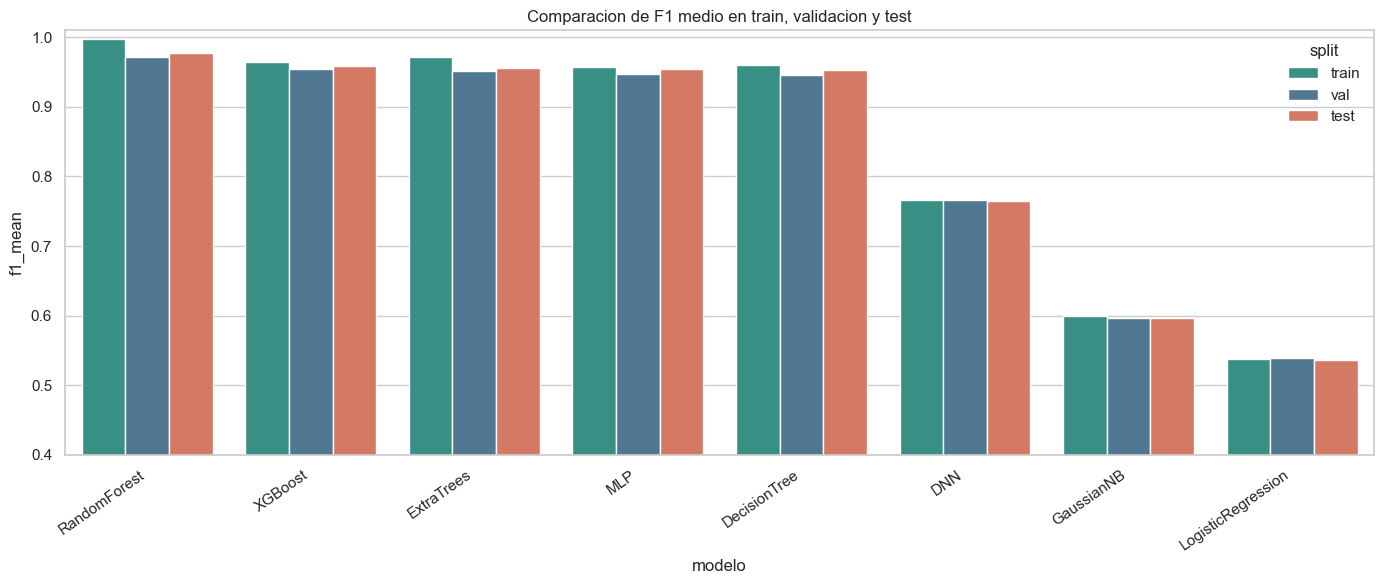

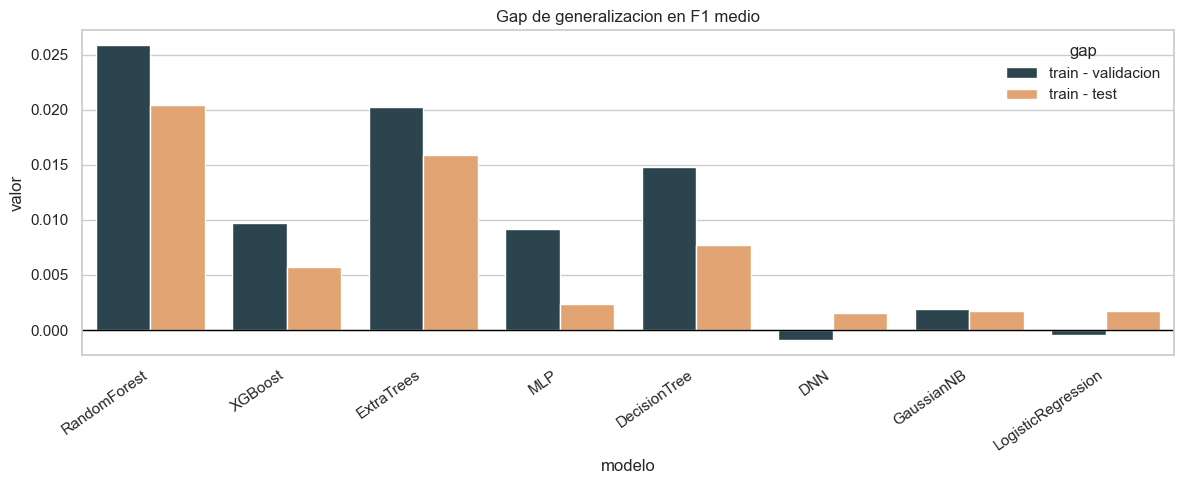

In [6]:
split_summary_long = metrics_df[
    [
        "modelo",
        "train_f1_mean",
        "val_f1_mean",
        "test_f1_mean",
        "train_auc_bin",
        "val_auc_bin",
        "test_auc_bin",
        "train_fpr_bin",
        "val_fpr_bin",
        "test_fpr_bin",
    ]
].copy()

train_ranking = metrics_df[["modelo", "train_f1_bin", "train_f1_cat", "train_f1_type", "train_f1_mean"]].copy()
val_ranking = metrics_df[["modelo", "val_f1_bin", "val_f1_cat", "val_f1_type", "val_f1_mean"]].copy()
test_ranking = metrics_df[["modelo", "test_f1_bin", "test_f1_cat", "test_f1_type", "test_f1_mean"]].copy()

display(train_ranking)
display(val_ranking)
display(test_ranking)

train_ranking.to_csv(TABLES_DIR / "ranking_train.csv", index=False)
val_ranking.to_csv(TABLES_DIR / "ranking_validacion.csv", index=False)
test_ranking.to_csv(TABLES_DIR / "ranking_test.csv", index=False)

comparison_df = metrics_df[["modelo", "train_f1_mean", "val_f1_mean", "test_f1_mean"]].melt(
    id_vars="modelo",
    var_name="split",
    value_name="f1_mean",
)
comparison_df["split"] = comparison_df["split"].str.replace("_f1_mean", "", regex=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=comparison_df, x="modelo", y="f1_mean", hue="split", palette=["#2a9d8f", "#457b9d", "#e76f51"])
plt.title("Comparacion de F1 medio en train, validacion y test")
plt.ylim(0.40, 1.01)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparacion_f1_train_val_test.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close()

gap_df = metrics_df[["modelo", "gap_train_val_f1_mean", "gap_train_test_f1_mean"]].melt(
    id_vars="modelo",
    var_name="gap",
    value_name="valor",
)
gap_df["gap"] = gap_df["gap"].map(
    {
        "gap_train_val_f1_mean": "train - validacion",
        "gap_train_test_f1_mean": "train - test",
    }
)

plt.figure(figsize=(12, 5))
sns.barplot(data=gap_df, x="modelo", y="valor", hue="gap", palette=["#264653", "#f4a261"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Gap de generalizacion en F1 medio")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gap_generalizacion_f1.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close()


### 6. Curvas de aprendizaje y dinamica de entrenamiento <a name="6"></a>

Para cubrir la parte de dinamica de aprendizaje se muestran curvas reales de entrenamiento para los modelos que exponen esa informacion de forma natural:

- `DNN`: perdida y `F1 macro` por epoca.
- `XGBoost`: `mlogloss` en train y validacion por ronda de boosting.
- `MLP`: curva de perdida y puntuacion interna de validacion de `scikit-learn`.

Estas graficas permiten ver si el modelo sigue aprendiendo, si se estabiliza y si aparecen sintomas de sobreajuste antes de llegar al conjunto de prueba.


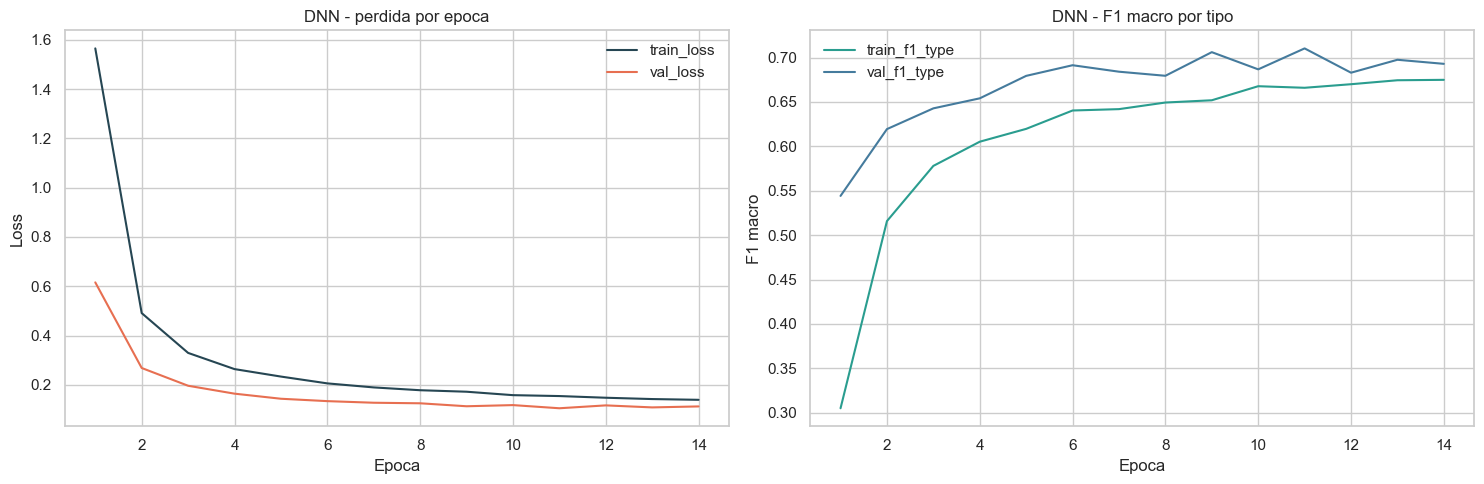

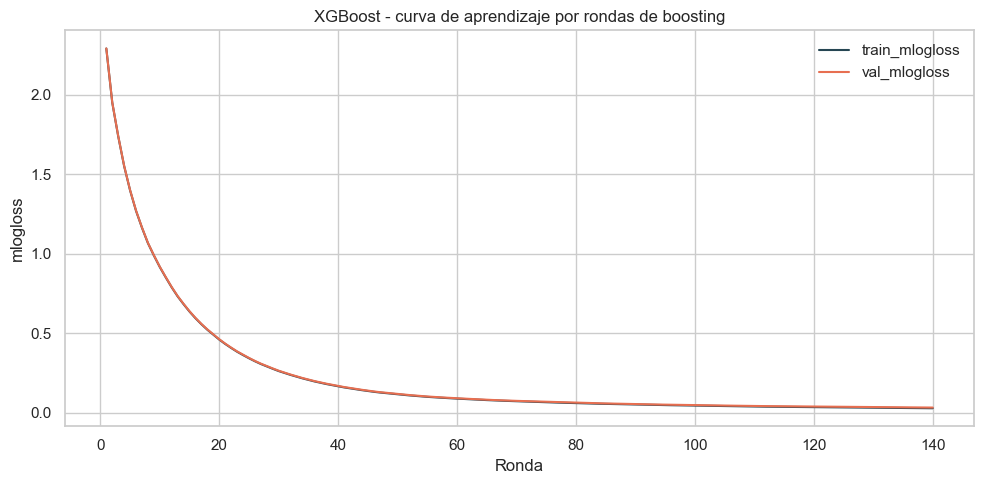

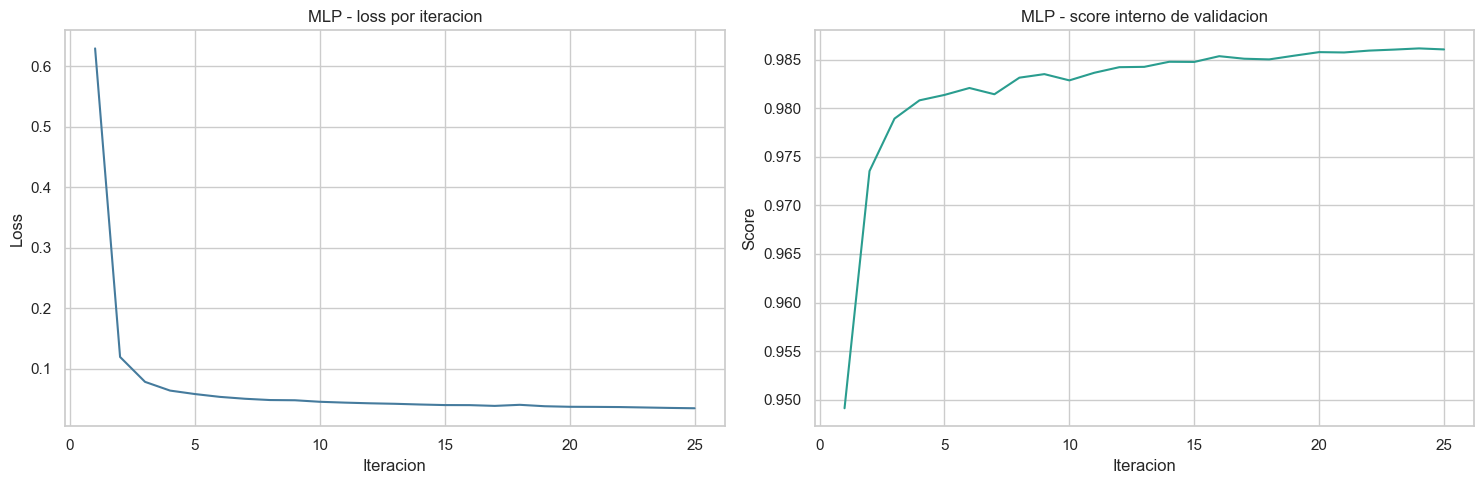

In [7]:
if "DNN" in history_frames:
    dnn_history = history_frames["DNN"].copy()
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(dnn_history["epoch"], dnn_history["train_loss"], label="train_loss", color="#264653")
    axes[0].plot(dnn_history["epoch"], dnn_history["val_loss"], label="val_loss", color="#e76f51")
    axes[0].set_title("DNN - perdida por epoca")
    axes[0].set_xlabel("Epoca")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(dnn_history["epoch"], dnn_history["train_f1_type"], label="train_f1_type", color="#2a9d8f")
    axes[1].plot(dnn_history["epoch"], dnn_history["val_f1_type"], label="val_f1_type", color="#457b9d")
    axes[1].set_title("DNN - F1 macro por tipo")
    axes[1].set_xlabel("Epoca")
    axes[1].set_ylabel("F1 macro")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "curvas_dnn.png", dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

if "XGBoost" in history_frames:
    xgb_history = history_frames["XGBoost"].copy()
    plt.figure(figsize=(10, 5))
    plt.plot(xgb_history["round"], xgb_history["train_mlogloss"], label="train_mlogloss", color="#264653")
    plt.plot(xgb_history["round"], xgb_history["val_mlogloss"], label="val_mlogloss", color="#e76f51")
    plt.title("XGBoost - curva de aprendizaje por rondas de boosting")
    plt.xlabel("Ronda")
    plt.ylabel("mlogloss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "curva_xgboost_mlogloss.png", dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

if "MLP" in history_frames:
    mlp_history = history_frames["MLP"].copy()
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(mlp_history["epoch"], mlp_history["train_loss"], color="#457b9d")
    axes[0].set_title("MLP - loss por iteracion")
    axes[0].set_xlabel("Iteracion")
    axes[0].set_ylabel("Loss")

    axes[1].plot(mlp_history["epoch"], mlp_history["val_score"], color="#2a9d8f")
    axes[1].set_title("MLP - score interno de validacion")
    axes[1].set_xlabel("Iteracion")
    axes[1].set_ylabel("Score")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "curvas_mlp.png", dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()


### 7. Resultados finales en test y metricas de negocio <a name="7"></a>

La tabla principal de test se completa ahora con dos capas de lectura:

1. **Rendimiento tecnico**: `F1`, `AUC-ROC`, `FPR`.
2. **Impacto operativo**: alertas manuales, ataques perdidos, horas de revision y coste asociado.

Esta segunda capa conecta directamente con los objetivos del Hito 1 y permite justificar la eleccion final del modelo no solo por precision estadistica, sino tambien por impacto sobre el equipo de seguridad.


,modelo,tiempo_entrenamiento_s,test_f1_bin,test_f1_cat,test_f1_type,test_f1_mean,test_auc_bin,test_fpr_bin
0,RandomForest,148.7400,0.9960,0.9786,0.9583,0.9777,0.9999,0.0022
1,XGBoost,215.8600,0.9887,0.9575,0.9288,0.9583,0.9999,0.0208
2,ExtraTrees,81.6100,0.9903,0.9532,0.9242,0.9559,0.9997,0.0155
3,MLP,72.2700,0.9875,0.9536,0.9225,0.9546,0.9991,0.0065
4,DecisionTree,10.6700,0.9863,0.9577,0.9146,0.9529,0.9984,0.0243
5,DNN,150.7100,0.8502,0.7357,0.7070,0.7643,0.9946,0.3316
6,GaussianNB,0.2300,0.6864,0.5410,0.5634,0.5969,0.5835,0.8626
7,LogisticRegression,156.3000,0.6843,0.4685,0.4555,0.5361,0.8945,0.8709


,modelo,test_f1_mean,test_manual_alerts,test_manual_alerts_per_1000,test_missed_attacks,test_review_hours,test_fp_cost_eur,test_total_operational_cost_eur,test_fpr_bin,test_auc_bin
0,RandomForest,0.9777,59721,485.0397,333,2986.0500,176.2500,74651.2500,0.0022,0.9999
1,XGBoost,0.9583,61169,496.8000,57,3058.4500,1641.2500,76461.2500,0.0208,0.9999
2,ExtraTrees,0.9559,60705,493.0315,187,3035.2500,1223.7500,75881.2500,0.0155,0.9997
3,MLP,0.9546,59249,481.2062,1074,2962.4500,512.5000,74061.2500,0.0065,0.9991
4,DecisionTree,0.9529,61329,498.0995,123,3066.4500,1923.7500,76661.2500,0.0243,0.9984
5,DNN,0.7643,80768,655.9784,108,4038.4000,26203.7500,100960.0000,0.3316,0.9946
6,GaussianNB,0.5969,114327,928.5366,113,5716.3500,68158.7500,142908.7500,0.8626,0.5835
7,LogisticRegression,0.5361,114852,932.8005,116,5742.6000,68818.7500,143565.0000,0.8709,0.8945


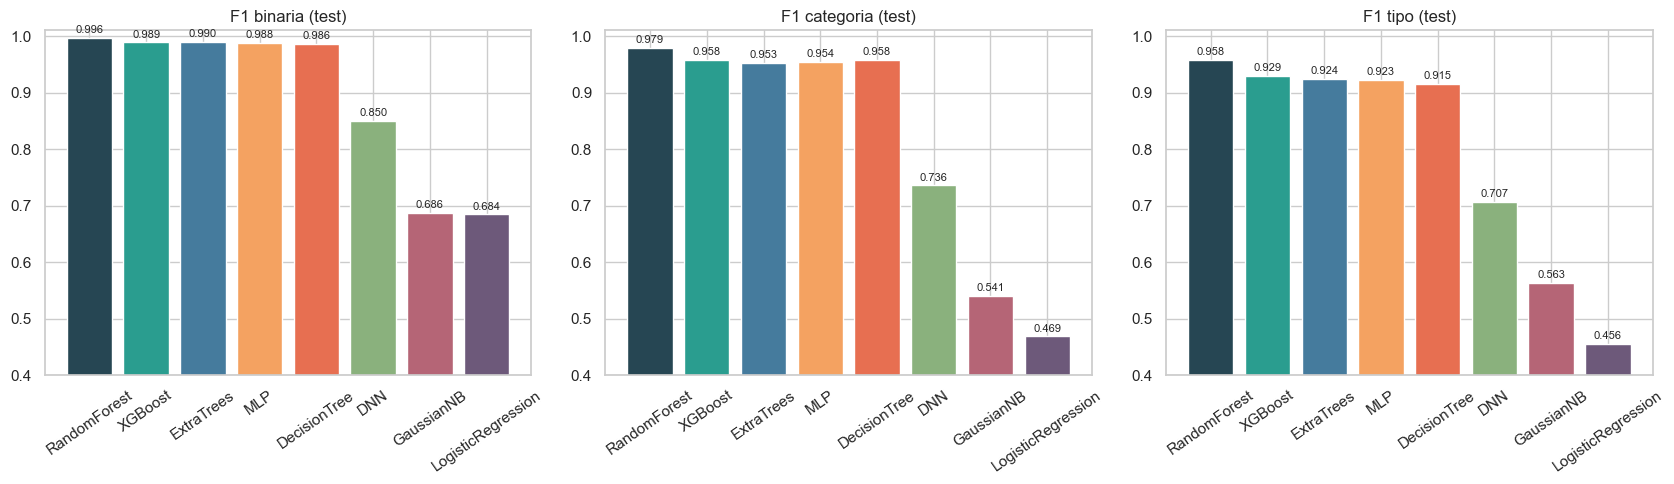

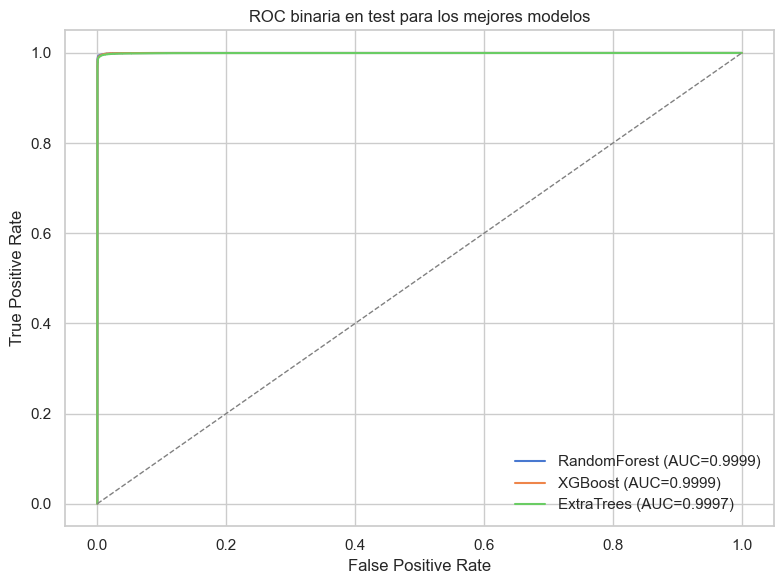

In [8]:
test_summary = metrics_df[
    [
        "modelo",
        "tiempo_entrenamiento_s",
        "test_f1_bin",
        "test_f1_cat",
        "test_f1_type",
        "test_f1_mean",
        "test_auc_bin",
        "test_fpr_bin",
    ]
].copy()
display(test_summary)
test_summary.to_csv(TABLES_DIR / "tabla_principal_test.csv", index=False)

operational_test = metrics_df[
    [
        "modelo",
        "test_f1_mean",
        "test_manual_alerts",
        "test_manual_alerts_per_1000",
        "test_missed_attacks",
        "test_review_hours",
        "test_fp_cost_eur",
        "test_total_operational_cost_eur",
        "test_fpr_bin",
        "test_auc_bin",
    ]
].copy()
display(operational_test)
operational_test.to_csv(TABLES_DIR / "metricas_operativas_test.csv", index=False)

metric_map = [
    ("test_f1_bin", "F1 binaria (test)"),
    ("test_f1_cat", "F1 categoria (test)"),
    ("test_f1_type", "F1 tipo (test)"),
]
colors = ["#264653", "#2a9d8f", "#457b9d", "#f4a261", "#e76f51", "#8ab17d", "#b56576", "#6d597a"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (col, title) in zip(axes, metric_map):
    ax.bar(metrics_df["modelo"], metrics_df[col], color=colors[: len(metrics_df)])
    ax.set_title(title)
    ax.set_ylim(0.40, 1.01)
    ax.tick_params(axis="x", rotation=35)
    for idx, value in enumerate(metrics_df[col]):
        ax.text(idx, value + 0.005, f"{value:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "f1_test_ampliado.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close()

top_models = metrics_df["modelo"].head(3).tolist()
y_test_attack = y_test_bin.map({"normal": 0, "attack": 1}).astype(int).to_numpy()

plt.figure(figsize=(8, 6))
for model_name in top_models:
    fpr, tpr, _ = roc_curve(y_test_attack, split_probabilities["test"][model_name])
    auc_value = metrics_df.loc[metrics_df["modelo"] == model_name, "test_auc_bin"].iloc[0]
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC binaria en test para los mejores modelos")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_test_top_models.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close()


**Resumen de resultados en test**

En la comparativa realizada sobre el conjunto de prueba, `RandomForest` obtiene el mejor equilibrio global, con una media simple de F1 de **0.9777**. A continuacion se situan ` XGBoost ` y ` ExtraTrees `, que refuerzan el buen comportamiento de los enfoques basados en arboles en este problema tabular.

En la salida binaria, el mejor modelo alcanza una `AUC-ROC` de **0.9999** y una `FPR` de **0.0022**. La clasificacion directa por tipo sigue siendo el nivel mas exigente del problema, aunque el bloque de cabeza mantiene un rendimiento alto y estable.


### 8. Analisis detallado de los mejores modelos <a name="8"></a>

El analisis detallado se concentra en los mejores modelos segun `test_f1_mean`. Se muestran dos vistas complementarias:

1. matrices de confusion por categoria para interpretar errores agregados,
2. clases mas dificiles segun `recall` medio para detectar donde siguen estando los limites del sistema.

Esta lectura es especialmente util en un problema tan desbalanceado, donde el resultado agregado puede ocultar errores importantes en tipos de ataque minoritarios.


,modelo,test_f1_type,test_f1_cat,test_f1_bin,test_f1_mean,test_auc_bin,test_fpr_bin
0,RandomForest,0.9583,0.9786,0.9960,0.9777,0.9999,0.0022
1,XGBoost,0.9288,0.9575,0.9887,0.9583,0.9999,0.0208
2,ExtraTrees,0.9242,0.9532,0.9903,0.9559,0.9997,0.0155


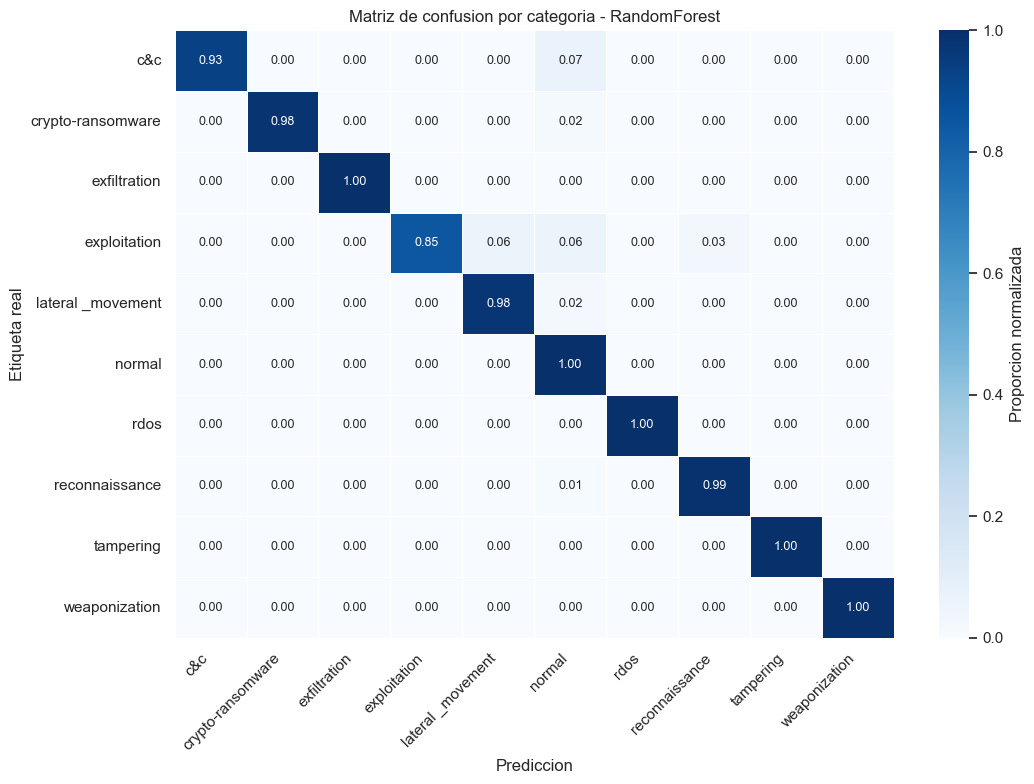

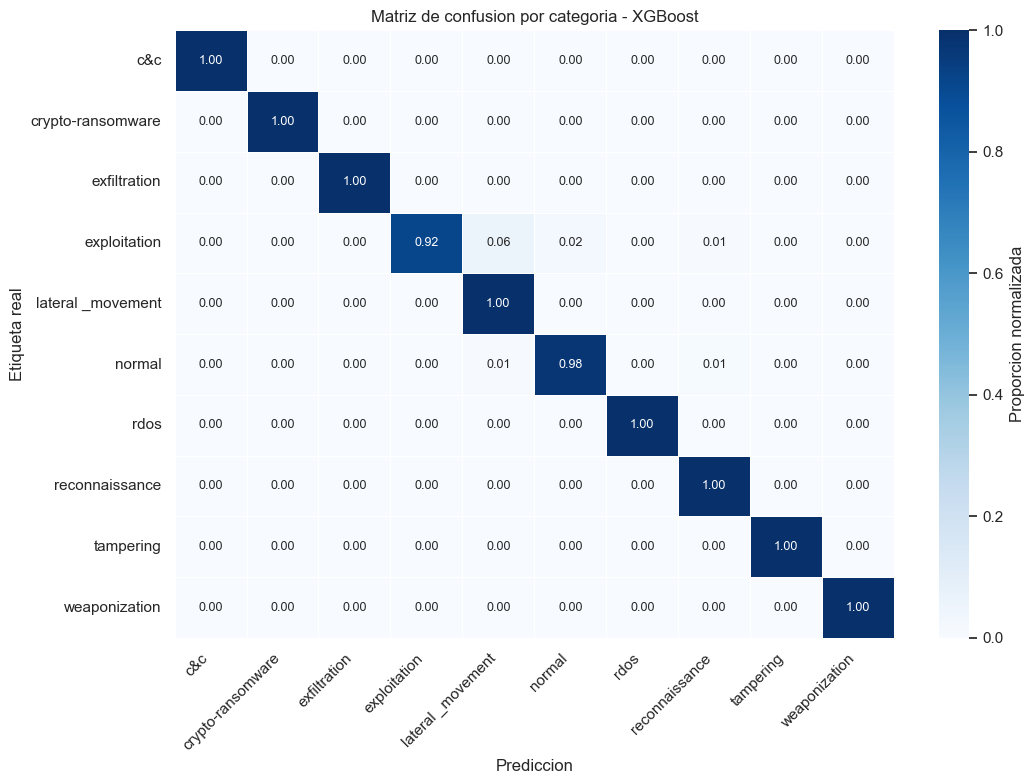

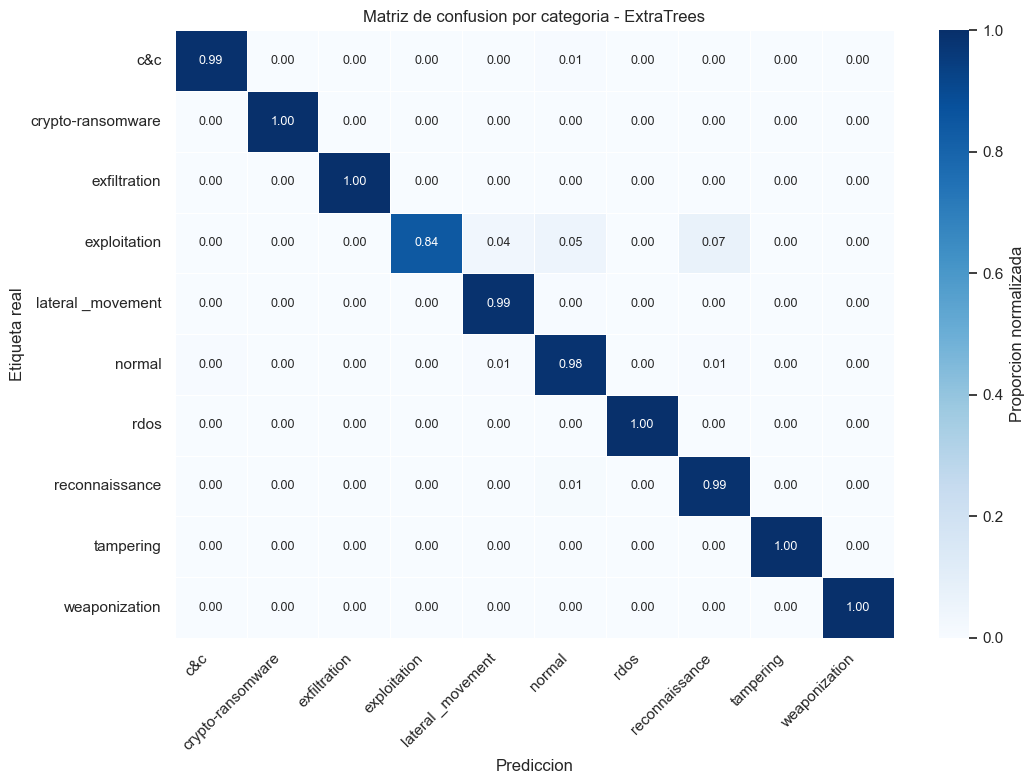

,support,recall_RandomForest,precision_RandomForest,recall_XGBoost,precision_XGBoost,recall_ExtraTrees,precision_ExtraTrees,mean_recall
mitm,19,0.7368,1.0000,0.9474,0.8182,0.6316,1.0000,0.7719
fuzzing,204,0.6569,0.9371,0.9412,0.4156,0.7647,0.4937,0.7876
tcp relay,352,0.7017,0.9427,0.9659,0.4521,0.9148,0.4857,0.8608
reverse_shell,176,0.8636,0.9620,0.9148,0.8944,0.8636,0.9441,0.8807
c&c,412,0.9320,0.9389,0.9976,0.7236,0.9927,0.5902,0.9741
discovering_resources,3410,0.9686,0.9807,0.9933,0.8982,0.9718,0.9578,0.9779
normal,63213,0.9978,0.9947,0.9792,0.9991,0.9845,0.9970,0.9872
crypto-ransomware,54,0.9815,0.9815,1.0000,0.8571,1.0000,0.9643,0.9938
mqtt_cloud_broker_subscription,3489,0.9980,0.9920,0.9986,0.9934,0.9960,0.9900,0.9975
generic_scanning,7517,0.9985,0.9980,0.9985,0.9977,0.9981,0.9946,0.9984


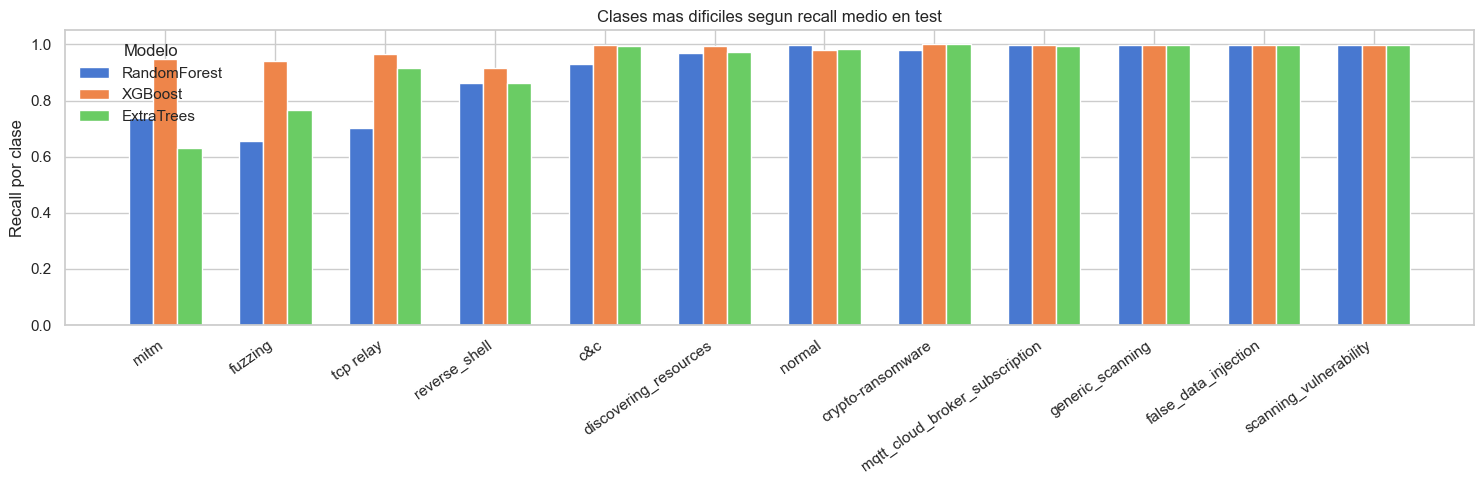

In [9]:
category_labels = sorted(mapping_df["class2"].unique().tolist())

top_models = metrics_df["modelo"].head(3).tolist()
model_summary = metrics_df[metrics_df["modelo"].isin(top_models)][
    ["modelo", "test_f1_type", "test_f1_cat", "test_f1_bin", "test_f1_mean", "test_auc_bin", "test_fpr_bin"]
].copy()
display(model_summary)
model_summary.to_csv(TABLES_DIR / "resumen_mejores_modelos.csv", index=False)

for model_name in top_models:
    pred_cat = split_predictions["test"][model_name].map(type_to_category)
    cm = confusion_matrix(y_test_cat, pred_cat, labels=category_labels, normalize="true")
    cm_df = pd.DataFrame(cm, index=category_labels, columns=category_labels)
    cm_df.to_csv(TABLES_DIR / f"matriz_confusion_categoria_{model_name}.csv")

    plt.figure(figsize=(11, 8))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 9},
        cbar_kws={"label": "Proporcion normalizada"},
    )
    plt.title(f"Matriz de confusion por categoria - {model_name}")
    plt.xlabel("Prediccion")
    plt.ylabel("Etiqueta real")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"matriz_confusion_categoria_{model_name}.png", dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

selected_reports = {model_name: reports_test[model_name] for model_name in top_models}
classes = [
    label
    for label in selected_reports[top_models[0]].index
    if label not in {"accuracy", "macro avg", "weighted avg"}
]

hard_classes = pd.DataFrame(
    {"support": selected_reports[top_models[0]].loc[classes, "support"].astype(int)}
)
for model_name in top_models:
    hard_classes[f"recall_{model_name}"] = selected_reports[model_name].loc[classes, "recall"]
    hard_classes[f"precision_{model_name}"] = selected_reports[model_name].loc[classes, "precision"]

hard_classes["mean_recall"] = hard_classes[[col for col in hard_classes.columns if col.startswith("recall_")]].mean(axis=1)
hard_classes = hard_classes.sort_values(["mean_recall", "support"]).head(12)
display(hard_classes)
hard_classes.to_csv(TABLES_DIR / "clases_mas_dificiles.csv")

plot_df = hard_classes.reset_index().rename(columns={"index": "clase"})
recall_cols = [col for col in plot_df.columns if col.startswith("recall_")]

x = np.arange(len(plot_df))
width = 0.22
fig, ax = plt.subplots(figsize=(15, 5))
for idx, col in enumerate(recall_cols):
    ax.bar(x + idx * width - width, plot_df[col], width=width, label=col.replace("recall_", ""))

ax.set_xticks(x)
ax.set_xticklabels(plot_df["clase"], rotation=35, ha="right")
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Recall por clase")
ax.set_title("Clases mas dificiles segun recall medio en test")
ax.legend(title="Modelo")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "clases_dificiles_recall.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close()


### 9. Conclusiones del modelado <a name="9"></a>

Las conclusiones siguientes sintetizan la lectura global del experimento a partir de las tablas y figuras presentadas en el cuaderno.


Tras el entrenamiento y la evaluacion sobre `class1`, la familia de modelos basada en arboles vuelve a situarse como la opcion mas solida del estudio. `RandomForest` ofrece el mejor compromiso global, mientras que `XGBoost` y `ExtraTrees` confirman que las relaciones no lineales del problema se capturan mejor con este tipo de enfoques.

La comparativa entre `train`, `validacion` y `test` muestra un comportamiento estable en los modelos con mejor rendimiento, sin cambios bruscos de jerarquia entre particiones. En el mejor modelo, el gap entre entrenamiento y test se mantiene en **0.0204**, lo que resulta coherente con una buena capacidad de generalizacion.

Desde la perspectiva neuronal, `MLP` mantiene un rendimiento competitivo dentro del bloque principal, mientras que la `DNN` no llega a superar a los mejores modelos clasicos con la configuracion utilizada en esta ejecucion. En terminos operativos, el menor volumen de alertas manuales por 1000 eventos corresponde a **MLP**, con **481.21** alertas por cada 1000 registros evaluados.
